# Mục tiêu của notebook này:

So sánh các mô hình

Phân tích lỗi dự đoán

Kiểm tra drift theo năm

Phân tích seasonality

Phân tích vùng hiếm (rare regions) F1

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
r"D:\HocTap\DATA_MINING\DATA_MINING_PROJECT\data\processed\crop_processed.csv"
)

df = df.rename(columns={"hg/ha_yield":"yield"})

# Cell 1 : Load kết quả mô hình


In [8]:
results = pd.read_csv(
r"D:\HocTap\DATA_MINING\DATA_MINING_PROJECT\data\processed\model_results.csv"
)

results

,Model,MAE,RMSE
0,Linear Regression,72558.353179,93281.764023
1,Random Forest,8906.468356,18149.461682
2,XGBoost,12210.184570,21249.000729


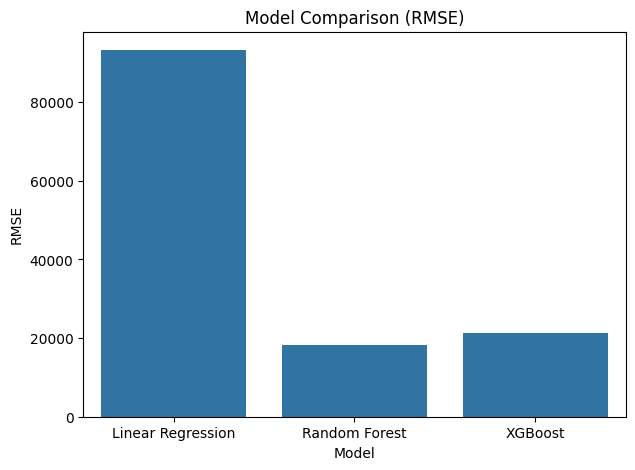

In [10]:
plt.figure(figsize=(7,5))

sns.barplot(
x="Model",
y="RMSE",
data=results
)

plt.title("Model Comparison (RMSE)")

plt.show()

# Cell 3 : Phân tích lỗi dự đoán


In [16]:
pred_df = pd.read_csv(
r"D:\HocTap\DATA_MINING\DATA_MINING_PROJECT\data\processed\prediction_xgb.csv"
)

pred_df.head()

,Actual,Predicted
0,69533,60235.613
1,260110,190652.980
2,10000,20941.256
3,41292,32080.504
4,33649,45178.742


In [18]:
pred_df = pd.read_csv(
r"D:\HocTap\DATA_MINING\DATA_MINING_PROJECT\data\processed\prediction_xgb.csv"
)

pred_df.head()

,Actual,Predicted
0,69533,60235.613
1,260110,190652.980
2,10000,20941.256
3,41292,32080.504
4,33649,45178.742


# Cell 4 : Tính Error


In [19]:
pred_df["Error"] = pred_df["Actual"] - pred_df["Predicted"]

pred_df.head()

,Actual,Predicted,Error
0,69533,60235.613,9297.387
1,260110,190652.980,69457.020
2,10000,20941.256,-10941.256
3,41292,32080.504,9211.496
4,33649,45178.742,-11529.742


Vẽ biểu đồ Error Distribution

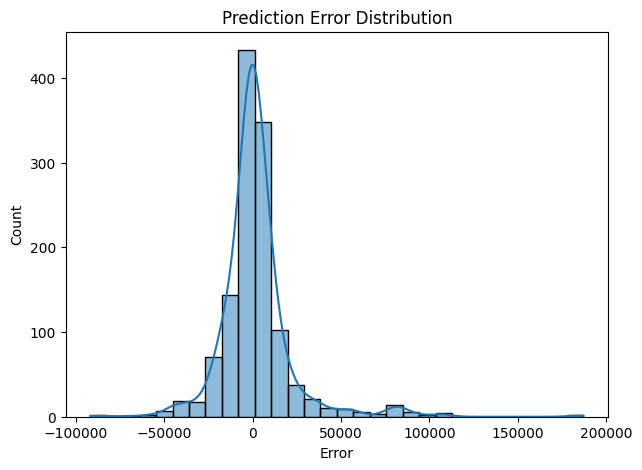

In [20]:
plt.figure(figsize=(7,5))

sns.histplot(pred_df["Error"], bins=30, kde=True)

plt.title("Prediction Error Distribution")

plt.show()

# Cell 5 : Biểu đồ Actual vs Predicted


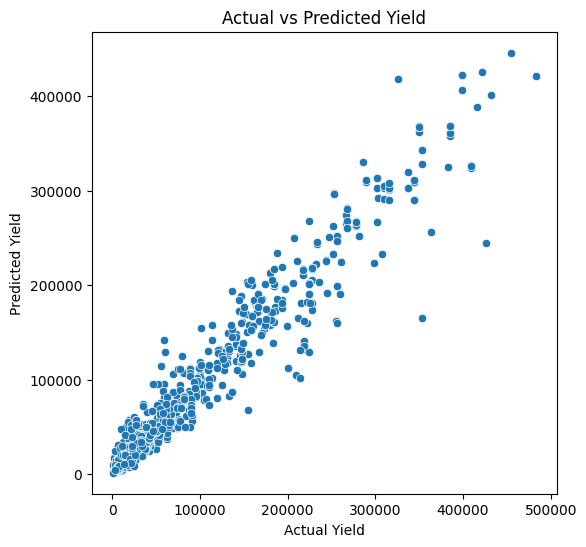

In [21]:
plt.figure(figsize=(6,6))

sns.scatterplot(
x=pred_df["Actual"],
y=pred_df["Predicted"]
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")

plt.title("Actual vs Predicted Yield")

plt.show()

Nếu model tốt:

các điểm nằm gần đường chéo

Ý nghĩa:

Error gần 0 → model chính xác

Error lớn → model dự đoán sai